In [1]:
import pandas as pd

from src import ttl, io
import numpy as np
import pandas
import glob
import os
import matplotlib.pyplot as plt

In [2]:
# set main data path
base_data_path = "/Volumes/AhmedLab/princess/data"
exp = 101

# set experiment file path
raw_path = glob.glob(os.path.join(base_data_path, 'raw', f'*{exp}'))[0]
csv_path = glob.glob(os.path.join(raw_path, '*.csv'))[0]
# load csv file


In [3]:
ttl_csv = ttl.read_csv(csv_path)
scope_timestamps = ttl.extract_2p_relative_timestamps(ttl_csv)
camera_timestamps = ttl.extract_camera_relative_timestamps(ttl_csv)
scope_framerate = ttl.get_frame_rate(pd.Series(scope_timestamps))
camera_framerate = ttl.get_frame_rate(pd.Series(camera_timestamps))

(0.0, 100.0)

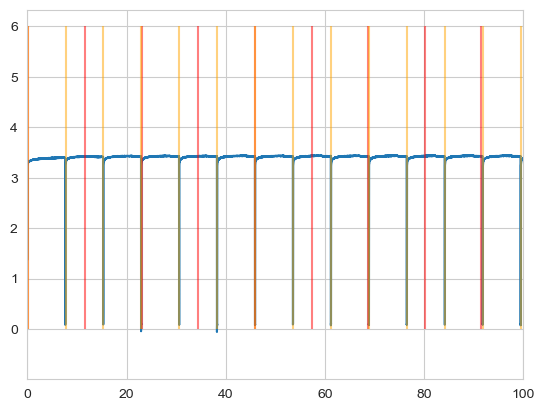

In [5]:
# plt.plot(ttl_csv['Time(ms)'], ttl_csv['Scope'], label='voltage recording')
plt.plot(ttl_csv['Time(ms)'], ttl_csv['Side Camera'])
# plt.plot(ttl_csv['Time(ms)'], scope_timestamps)
plt.vlines(scope_timestamps, 0, 6, colors='red', alpha=0.5, label='detected frames')
# plt.legend()
plt.vlines(camera_timestamps, 0, 6, colors='orange', alpha=0.5)
plt.xlim(0,100)

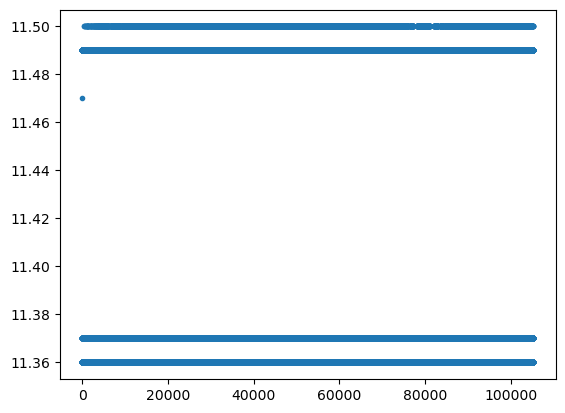

In [4]:
# is there a flyback time?
# in the video, it looks like there should be a flyback time
fr_time = np.diff(scope_timestamps) # in ms
plt.plot(fr_time, marker = '.', linestyle = 'none')


In [5]:
# what if I grab times from the xml
import xml.etree.ElementTree as ET

In [6]:
xml_file = glob.glob(os.path.join(raw_path, '*.xml'))[0]


In [7]:
csv_frames = scope_timestamps

tree = ET.parse(xml_file)
root = tree.getroot()
frames = [x.find("Frame") for x in root]
sequences = [x.find("Sequence") for x in root]

xml_frames = []
fr_index = []
for element in root.iter("Frame"):
    # time = float(element.attrib['absoluteTime'])
    time = float(element.attrib['relativeTime'])
    # print(time)
    xml_frames.append(time)
    fr_index.append(int(element.attrib['index']))

# from xml file
print(f'XML file: number of frames: {len(xml_frames)}, number of volumes(t): {len(frames)}')
# from csv file
csv_volumes = len(csv_frames)/31
print(f'CSV file: number of frames: {len(csv_frames)}, number of volumes(t): {csv_volumes}')


XML file: number of frames: 85777, number of volumes(t): 2769
CSV file: number of frames: 105149, number of volumes(t): 3391.9032258064517


In [25]:
# The number that matches exactly is xml_frames
# pulling the number of absoluteTimes from the xml
xml_timeseries = []
t_zero = xml_frames[0]
print(f't_zero: {t_zero}')

for fr in xml_frames:
  xml_timeseries.append(fr-t_zero)

# xml_timeseries saves out the correct frame start with first frame at time 0\
# parse_bruker_xml.m uses this method as well

# how well does this match csv timestamps?


t_zero: 0.079902067


In [13]:
# csv_frames = csv_frames/1000
# csv is in ms
# xml is in seconds


Text(0.5, 0, 'time(s)')

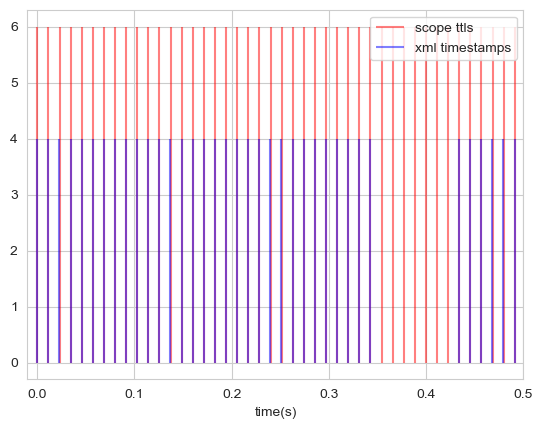

In [14]:
plt.vlines(csv_frames, 0, 6, colors='red', alpha=0.5, label='scope ttls')
plt.vlines(xml_timeseries, 0, 4, colors='blue', alpha=0.5, label='xml timestamps')
plt.legend()
plt.xlim(-0.01, .5)
plt.xlabel('time(s)')

In [9]:
# now for camera frames
# convert from seconds to ms
# camera_timestamps = camera_timestamps/1000

# pull start time of voltage recording from xml file
for element in root.iter('VoltageRecording'):
    volt_time = float(element.attrib['absoluteTime'])
    print(volt_time)

# zero the voltage recordings by subtracting the absolute time
camera_timeseries = []
t_zero = volt_time

for fr in camera_timestamps:
    zeroed = fr+t_zero
    camera_timeseries.append(zeroed/1000)
print(camera_timeseries[0])

0.131922900000063
0.000141922900000063


Text(0.5, 0, 'time(s)')

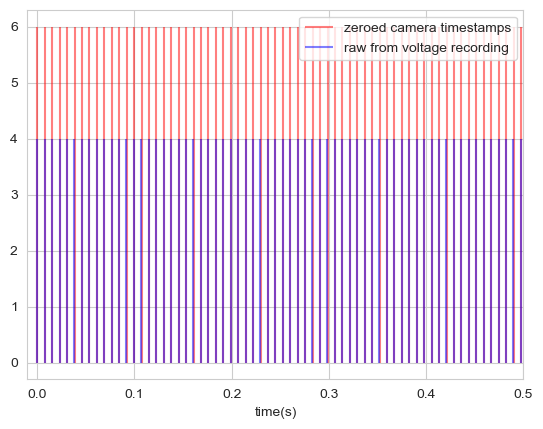

In [17]:
plt.vlines(camera_timeseries, 0, 6, colors='red', alpha=0.5, label='zeroed camera timestamps')
plt.vlines(camera_timestamps/1000, 0, 4, colors='blue', alpha=0.5, label='raw from voltage recording')
plt.legend()
plt.xlim(-0.01, 0.5)
plt.xlabel('time(s)')

# functions
- [x] extract scope timestamps from xml
- [] extract camera timestamps from csv
- [] what should be zero?
- [] summary plot
- [] calculate flyback and volume time
- [] extract laser power levels

# need to figure out
- do I use relative or absolute time?

In [27]:
print(len(frames))
xml_timeseries_arr = np.array(xml_timeseries) # .reshape(max(fr_index), -1)
print(xml_timeseries_arr.shape, max(fr_index))

2769
(85777,) 31


In [ ]:
# movement starts on volume 751
image_shift = 751
